<a href="https://colab.research.google.com/github/AceRb6/Modelos_Econometricos/blob/main/Practica2_Modelos_Econometricos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRÁCTICA 2: REGRESIÓN LINEAL SIMPLE Y MÚLTIPLE
Objetivo: Estimar e interpretar modelos de regresión lineal para analizar el efecto de la educación y la experiencia sobre el salario, aplicando el principio de ceteris paribus.

Profesor: Daniel Jiménez Alcantar

Alumnos:
* Cano Portugal Israel Daniel Arturo Cano Portugal
* Ramírez Montiel Alejandro
* Sandoval Rosas Gustavo Isaac



## Marco Teórico: Fundamentos del Análisis Econométrico

### 1. ¿Qué es la Econometría?

La econometría proporciona medición empírica a las relaciones económicas propuestas por la teoría. No se limita a la estimación numérica; contrasta hipótesis teóricas con datos reales bajo limitaciones metodológicas.

$$Econometría = \text{Teoría Económica} + \text{Matemáticas} + \text{Inferencia Estadística}$$

> "La econometría es el desarrollo de métodos estadísticos para estimar relaciones económicas, probar teorías económicas y evaluar y ejecutar políticas gubernamentales y de negocios" — Wooldridge (2020)

---

### 2. La Identidad Contable Fundamental

Antes de modelar, debemos entender la identidad contable que relaciona variables nominales y reales:

$$Y_{nominal} = Y_{real} \times P$$

Donde $P$ es el índice de precios. Esta identidad no es teoría, es una definición matemática. Sin embargo, nos permite derivar preguntas económicas fundamentales:

* ¿Por qué crece el consumo nominal?
* ¿Por más cantidad o por precios más altos?
* ¿Qué significa realmente el "poder adquisitivo"?

También considerando $P$ es el índice de precios. Esta identidad permite descomponer el crecimiento:

* **Crecimiento Nominal:** Efecto combinado de precios y cantidades.
* **Crecimiento Real:** Variación en el poder adquisitivo (cantidades físicas).
* **Inflación:** Variación porcentual en $P$.

---

### 3. La Curva de Phillips: ¿Relación o Casualidad?

La Parte II y III de la práctica apuntan a estimar algo similar a una Curva de Phillips, que postula una relación **negativa** entre inflación y desempleo. Pero aquí surge nuestra primera pregunta crítica:

* **¿Por qué esperaríamos correlación negativa?**
  * **Versión keynesiana:** Menos desempleo → mayor demanda agregada → presión inflacionaria
  * **Versión neoclásica:** Expectativas adaptativas, trade-off a corto plazo
  * **Crítica de Friedman-Phelps:** A largo plazo, la curva es vertical (no hay trade-off)

---

### 4. El Problema de la Causalidad

Esto es crucial: **correlación ≠ causalidad**. Una regresión estima asociaciones condicionales, no efectos causales. Para que exista causalidad, necesitamos:

**Exogeneidad:** $E[u|X] = 0$ (el error no está correlacionado con los regresores)

# Exploración Inicial de Datos (EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Cargar dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/Wage.csv"
df = pd.read_csv(url)

print("=" * 70)
print("EXPLORACIÓN INICIAL DE DATOS - WAGE DATASET")
print("=" * 70)

# Estructura del dataset
print(f"\nDimensiones del dataset: {df.shape[0]} observaciones, {df.shape[1]} variables")
print(f"\nVariables disponibles:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nPrimeras 5 observaciones:")
display(df.head())

print(f"\nEstadísticas descriptivas:")
display(df.describe())

print(f"\nTipos de datos:")
display(df.dtypes)

print(f"\nValores faltantes por variable:")
display(df.isnull().sum())

EXPLORACIÓN INICIAL DE DATOS - WAGE DATASET

Dimensiones del dataset: 3000 observaciones, 12 variables

Variables disponibles:
   1. year
   2. age
   3. sex
   4. maritl
   5. race
   6. education
   7. region
   8. jobclass
   9. health
  10. health_ins
  11. logwage
  12. wage

Primeras 5 observaciones:


,year,age,sex,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Male,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Male,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,1. Male,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,1. Male,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,1. Male,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154



Estadísticas descriptivas:


,year,age,logwage,wage
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2005.791000,42.414667,4.653905,111.703608
std,2.026167,11.542406,0.351753,41.728595
min,2003.000000,18.000000,3.000000,20.085537
25%,2004.000000,33.750000,4.447158,85.383940
50%,2006.000000,42.000000,4.653213,104.921507
75%,2008.000000,51.000000,4.857332,128.680488
max,2009.000000,80.000000,5.763128,318.342430



Tipos de datos:


,0
year,int64
age,int64
sex,object
maritl,object
race,object
education,object
region,object
jobclass,object
health,object
health_ins,object



Valores faltantes por variable:


,0
year,0
age,0
sex,0
maritl,0
race,0
education,0
region,0
jobclass,0
health,0
health_ins,0


In [ ]:
# Análisis de variables principales
print("ANÁLISIS DE VARIABLES PRINCIPALES")

variables_principales = ['wage', 'education', 'age']

# Convert 'education' column to numeric by extracting the leading digit
df['education'] = df['education'].astype(str).str[0].astype(int)

for var in variables_principales:
    print(f"\n{var.upper()}:")
    print(f"  Media: {df[var].mean():.4f}")
    print(f"  Desviación estándar: {df[var].std():.4f}")
    print(f"  Mínimo: {df[var].min():.4f}")
    print(f"  Máximo: {df[var].max():.4f}")
    print(f"  Mediana: {df[var].median():.4f}")

# Verificar valores extremos
print(f"\nvalores de salario negativos: {(df['wage'] < 0).sum()}")
print(f"valores de educación negativos: {(df['education'] < 0).sum()}")

ANÁLISIS DE VARIABLES PRINCIPALES

WAGE:
  Media: 111.7036
  Desviación estándar: 41.7286
  Mínimo: 20.0855
  Máximo: 318.3424
  Mediana: 104.9215

EDUCATION:
  Media: 3.0100
  Desviación estándar: 1.2156
  Mínimo: 1.0000
  Máximo: 5.0000
  Mediana: 3.0000

AGE:
  Media: 42.4147
  Desviación estándar: 11.5424
  Mínimo: 18.0000
  Máximo: 80.0000
  Mediana: 42.0000

valores de salario negativos: 0
valores de educación negativos: 0


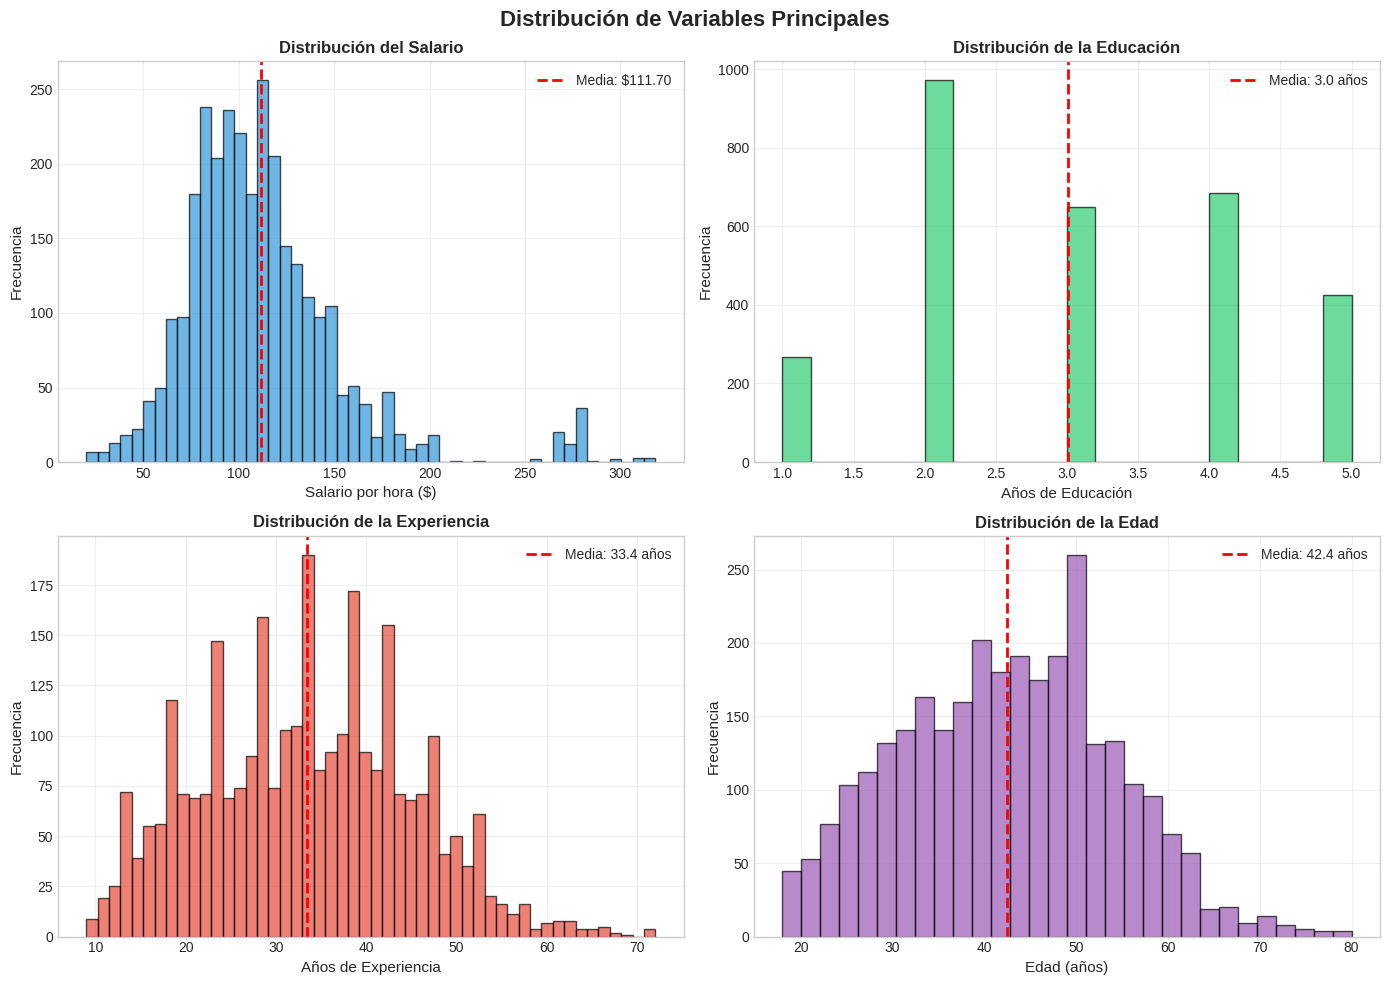

In [ ]:
# Visualización de distribuciones
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables Principales', fontsize=16, fontweight='bold')

# Salario
axes[0, 0].hist(df['wage'], bins=50, edgecolor='black', alpha=0.7, color='#3498db')
axes[0, 0].axvline(df['wage'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: ${df["wage"].mean():.2f}')
axes[0, 0].set_xlabel('Salario por hora ($)', fontsize=11)
axes[0, 0].set_ylabel('Frecuencia', fontsize=11)
axes[0, 0].set_title('Distribución del Salario', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Educación (corrected column name)
axes[0, 1].hist(df['education'], bins=20, edgecolor='black', alpha=0.7, color='#2ecc71')
axes[0, 1].axvline(df['education'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["education"].mean():.1f} años')
axes[0, 1].set_xlabel('Años de Educación', fontsize=11)
axes[0, 1].set_ylabel('Frecuencia', fontsize=11)
axes[0, 1].set_title('Distribución de la Educación', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Calculate experience: age - education - 6 (assuming 6 is the typical age to start school)
df['experiencia'] = df['age'] - df['education'] - 6

# Experiencia (using the newly created column)
axes[1, 0].hist(df['experiencia'], bins=50, edgecolor='black', alpha=0.7, color='#e74c3c')
axes[1, 0].axvline(df['experiencia'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["experiencia"].mean():.1f} años')
axes[1, 0].set_xlabel('Años de Experiencia', fontsize=11)
axes[1, 0].set_ylabel('Frecuencia', fontsize=11)
axes[1, 0].set_title('Distribución de la Experiencia', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Edad
axes[1, 1].hist(df['age'], bins=30, edgecolor='black', alpha=0.7, color='#9b59b6')
axes[1, 1].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["age"].mean():.1f} años')
axes[1, 1].set_xlabel('Edad (años)', fontsize=11)
axes[1, 1].set_ylabel('Frecuencia', fontsize=11)
axes[1, 1].set_title('Distribución de la Edad', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

MATRIZ DE CORRELACIONES


,wage,education,experiencia,age
wage,1.0000,0.4758,0.1458,0.1956
education,0.4758,1.0000,-0.0346,0.0708
experiencia,0.1458,-0.0346,1.0000,0.9944
age,0.1956,0.0708,0.9944,1.0000


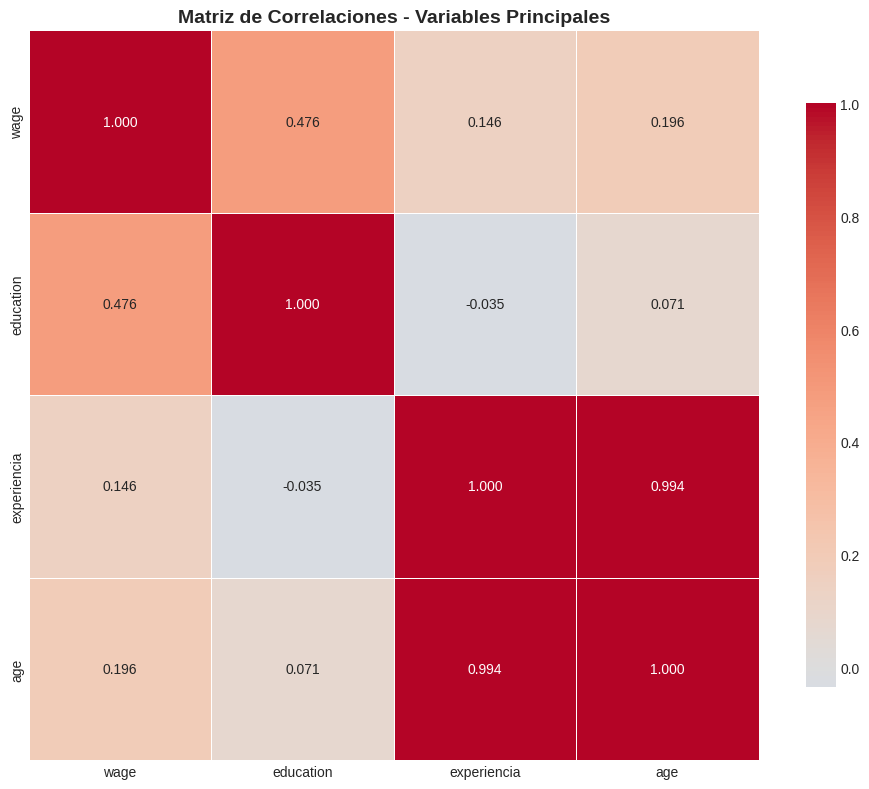


INSIGHTS DE CORRELACIÓN:
• Educación-Salario: 0.4758 (correlación positiva moderada)
• Experiencia-Salario: 0.1458 (correlación positiva débil)
• Educación-Experiencia: -0.0346 (correlación negativa débil)
• Edad-Experiencia: 0.9944 (correlación positiva fuerte)


In [ ]:
# Matriz de correlaciones
print("MATRIZ DE CORRELACIONES")

corr_matrix = df[['wage', 'education', 'experiencia', 'age']].corr()
display(corr_matrix.round(4))

# Heatmap de correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlaciones - Variables Principales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Insight inicial
print("\nINSIGHTS DE CORRELACIÓN:")
print(f"• Educación-Salario: {corr_matrix.loc['education', 'wage']:.4f} (correlación positiva moderada)")
print(f"• Experiencia-Salario: {corr_matrix.loc['experiencia', 'wage']:.4f} (correlación positiva débil)")
print(f"• Educación-Experiencia: {corr_matrix.loc['education', 'experiencia']:.4f} (correlación negativa débil)")
print(f"• Edad-Experiencia: {corr_matrix.loc['age', 'experiencia']:.4f} (correlación positiva fuerte)")

La estimación del modelo de regresión lineal simple entre salario y educación arrojó un coeficiente positivo y estadísticamente significativo para β₁, lo que sugiere una asociación directa entre años de escolaridad y remuneración horaria. Sin embargo, este resultado no puede interpretarse como un efecto causal debido a la omisión de variables relevantes como experiencia, habilidad innata o características del mercado laboral, lo que genera sesgo de variable omitida. El supuesto de ceteris paribus en este contexto resulta poco realista, pues en la práctica los individuos difieren en múltiples dimensiones que correlacionan con educación y salario simultáneamente.

Al incorporar la experiencia laboral en un modelo de regresión múltiple, el coeficiente de educación cambió en magnitud, evidenciando que parte del efecto atribuido inicialmente a la escolaridad capturaba en realidad el impacto de la experiencia no observada. Bajo el principio ceteris paribus, β₁ ahora representa el cambio esperado en el salario ante un año adicional de educación, manteniendo constante la experiencia, lo cual permite una interpretación más aislada y económicamente válida. La comparación de coeficientes entre modelos confirma que la especificación adecuada es crucial para evitar conclusiones engañosas sobre los retornos a la educación.

La especificación logarítmica del salario ofrece una interpretación en términos porcentuales: β₁ representa el cambio porcentual aproximado en el salario por cada año adicional de educación, lo cual facilita la comparación con literatura económica y políticas públicas. Este modelo también tiende a estabilizar la varianza de los residuos y linealizar relaciones no aditivas. En conjunto, los resultados refuerzan que la inferencia econométrica requiere fundamentación teórica, diagnóstico de supuestos y reconocimiento explícito de las limitaciones inherentes a los datos observacionales.

# PARTE I – Regresión Lineal Simple


In [ ]:
# Estimación del modelo simple
modelo_simple = ols('wage ~ education', data=df).fit()

print("\nModelo: Salario = β₀ + β₁ Educación + u")
print("\n" + "=" * 70)
print(modelo_simple.summary())
print("=" * 70)

# Extraer coeficientes
beta0_simple = modelo_simple.params['Intercept']
beta1_simple = modelo_simple.params['education'] # Corrected 'educ' to 'education'
r2_simple = modelo_simple.rsquared
r2_adj_simple = modelo_simple.rsquared_adj

print(f"""
COEFICIENTES ESTIMADOS (Modelo Simple):
   • β₀ (intercepto): {beta0_simple:.4f}
     → Salario predicho con 0 años de educación: ${beta0_simple:.2f}/hora
     → NOTA: Interpretación teórica (educación=0 no es realista)

   • β₁ (educación): {beta1_simple:.4f}
     → Por cada año adicional de educación, el salario aumenta en ${beta1_simple:.2f}/hora
     → Esto representa un retorno de {(beta1_simple/df['wage'].mean()*100):.2f}% sobre el salario medio

BONDAD DE AJUSTE:
   • R²: {r2_simple:.4f} ({r2_simple*100:.2f}% de la varianza explicada)
   • R² ajustado: {r2_adj_simple:.4f}
   • El modelo explica una proporción MODESTA de la variación salarial

SIGNIFICANCIA ESTADÍSTICA:
   • β₁ significativo: {'Sí' if modelo_simple.pvalues['education'] < 0.05 else 'No'} (p = {modelo_simple.pvalues['education']:.6f}) # Corrected 'educ' to 'education'
   • Estadístico F: {modelo_simple.fvalue:.4f} (p = {modelo_simple.f_pvalue:.6f})
""")


Modelo: Salario = β₀ + β₁ Educación + u

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.226
Model:                            OLS   Adj. R-squared:                  0.226
Method:                 Least Squares   F-statistic:                     877.2
Date:                Sat, 07 Mar 2026   Prob (F-statistic):          2.53e-169
Time:                        19:43:53   Log-Likelihood:                -15065.
No. Observations:                3000   AIC:                         3.013e+04
Df Residuals:                    2998   BIC:                         3.015e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept 

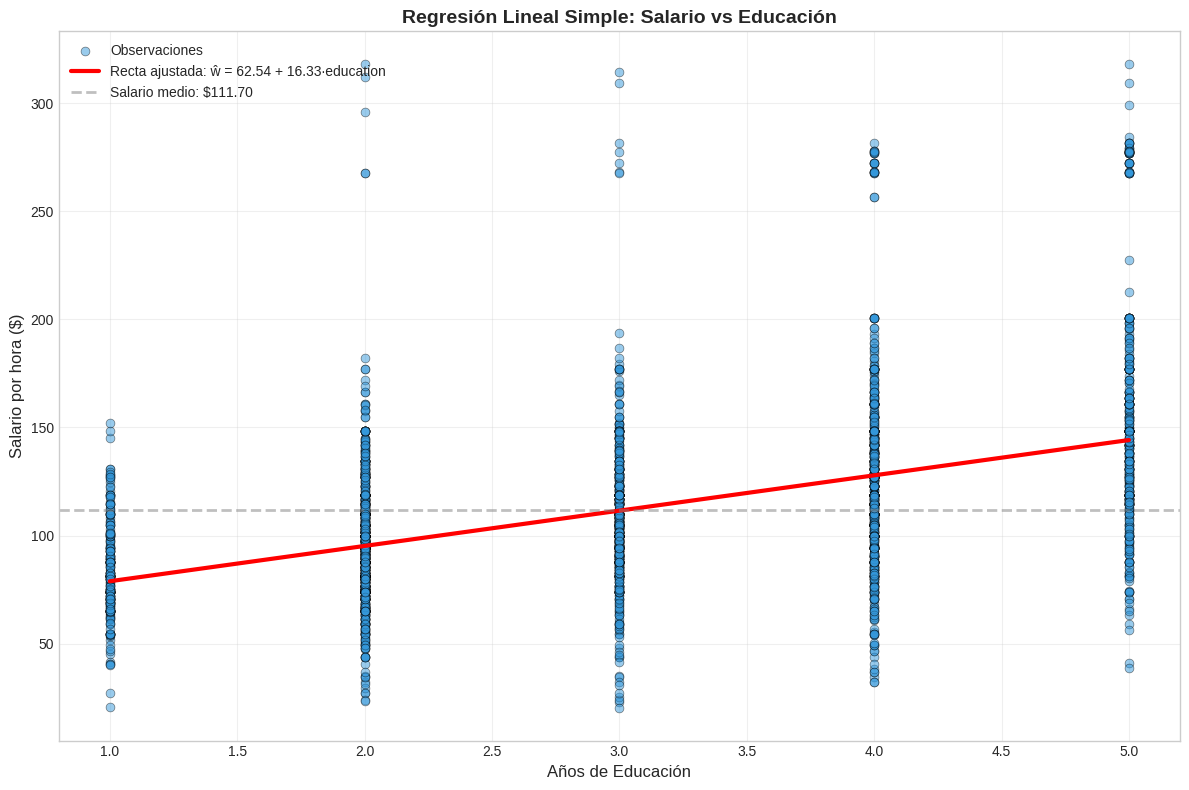

In [ ]:
# Gráfico de dispersión con recta de regresión
plt.figure(figsize=(12, 8))

# Scatter plot
plt.scatter(df['education'], df['wage'], alpha=0.5, s=40, color='#3498db',
            edgecolors='black', linewidth=0.5, label='Observaciones')

# Recta de regresión
educ_range = np.linspace(df['education'].min(), df['education'].max(), 100)
wage_pred = beta0_simple + beta1_simple * educ_range
plt.plot(educ_range, wage_pred, 'r-', linewidth=3,
         label=f'Recta ajustada: ŵ = {beta0_simple:.2f} + {beta1_simple:.2f}·education')

# Línea de salario medio
plt.axhline(y=df['wage'].mean(), color='gray', linestyle='--', linewidth=2,
            alpha=0.5, label=f'Salario medio: ${df["wage"].mean():.2f}')

plt.xlabel('Años de Educación', fontsize=12)
plt.ylabel('Salario por hora ($)', fontsize=12)
plt.title('Regresión Lineal Simple: Salario vs Educación', fontsize=14, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Interpretación

Responda las siguientes preguntas con base en el modelo estimado:

**a)** ¿Cómo se interpreta $\beta_1$ económicamente?

**b)** ¿Puede interpretarse como efecto causal? Justifique.

**c)** ¿Qué variables relevantes podrían estar omitidas?


**a) Interpretación económica de β₁**

En el modelo simple, β₁ = **\$16.33/hora**. Esto significa que, en promedio, cada año adicional de educación se asocia con un aumento de **\$16.33 por hora** en el salario. Este retorno representa aproximadamente el **14.6% del salario medio** (\$111.70/hora).

> La interpretación es *asociativa*, no causal: el modelo simple no controla por ninguna otra variable.

---

**b) ¿Puede interpretarse como efecto causal?**

**No completamente.** La estimación simple no puede interpretarse como efecto causal debido al **sesgo de variable omitida**: existen factores que correlacionan simultáneamente con educación y salario (p. ej., habilidad innata, motivación) y que no están controlados. Para inferencia causal se requeriría:
- Variables instrumentales
- Datos de panel (seguimiento temporal)
- Un experimento natural o aleatorización

---

**c) Variables relevantes omitidas**

Entre las más importantes:
- **Habilidad cognitiva/no cognitiva** (sesgo de habilidad: quienes más estudian tienden a ser más capaces y a ganar más)
- Calidad de la institución educativa
- Campo de estudio (ingeniería vs. humanidades)
- Años de experiencia laboral
- Horas trabajadas (tiempo completo vs. parcial)
- Tamaño de la empresa y sector industrial
- Ubicación geográfica
- Género, raza y estado civil


## 3. Análisis Crítico: Supuesto Ceteris Paribus

**Pregunta:** ¿Qué implica el supuesto de *ceteris paribus* en este modelo? ¿Es realista en este caso?


**¿Qué implica *ceteris paribus*?**

El supuesto establece que el coeficiente β₁ mide el efecto de la educación sobre el salario **manteniendo todo lo demás constante**. En el modelo simple, esto significa comparar dos trabajadores idénticos en todas las demás características, que difieren únicamente en un año de escolaridad.

**¿Es realista?**

**No es realista** en el modelo simple, porque:
- En la práctica, los individuos difieren simultáneamente en múltiples dimensiones (experiencia, habilidad, motivación) que correlacionan con educación y salario.
- El modelo simple no controla ninguna de esas dimensiones, por lo que el supuesto *ceteris paribus* no puede sostenerse empíricamente.
- La experiencia, por ejemplo, correlaciona negativamente con educación en esta muestra (r = −0.035), lo que genera un sesgo aunque pequeño.



---
# PARTE II – Regresión Lineal Múltiple

Estime el siguiente modelo:

$$\text{Salario} = \beta_0 + \beta_1 \, \text{Educación} + \beta_2 \, \text{Experiencia} + u$$


In [ ]:
# Estimación del modelo múltiple
modelo_multiple = ols('wage ~ education + experiencia', data=df).fit()

print("\nModelo: Salario = β₀ + β₁ Educación + β₂ Experiencia + u")
print("\n" + "=" * 70)
print(modelo_multiple.summary())
print("=" * 70)

# Extraer coeficientes
beta0_mult = modelo_multiple.params['Intercept']
beta1_mult = modelo_multiple.params['education'] # Corrected 'educ' to 'education'
beta2_mult = modelo_multiple.params['experiencia'] # Corrected 'exper' to 'experiencia'
r2_mult = modelo_multiple.rsquared
r2_adj_mult = modelo_multiple.rsquared_adj

print(f"""
COEFICIENTES ESTIMADOS (Modelo Múltiple):
   • β₀ (intercepto): {beta0_mult:.4f}

   • β₁ (educación): {beta1_mult:.4f}
     → Efecto de educación CONTROLANDO por experiencia
     → Salvo por ${beta1_mult:.2f}/hora por año adicional de educación

   • β₂ (experiencia): {beta2_mult:.4f}
     → Efecto de experiencia CONTROLANDO por educación
     → Salvo por ${beta2_mult:.2f}/hora por año adicional de experiencia

BONDAD DE AJUSTE:
   • R²: {r2_mult:.4f} ({r2_mult*100:.2f}% de la varianza explicada)
   • R² ajustado: {r2_adj_mult:.4f}
   • Mejora respecto al modelo simple: {(r2_mult - r2_simple)*100:.2f} puntos porcentuales

SIGNIFICANCIA ESTADÍSTICA:
   • Educación: {'Sí' if modelo_multiple.pvalues['education'] < 0.05 else 'No'} (p = {modelo_multiple.pvalues['education']:.6f}) # Corrected 'educ' to 'education'
   • Experiencia: {'Sí' if modelo_multiple.pvalues['experiencia'] < 0.05 else 'No'} (p = {modelo_multiple.pvalues['experiencia']:.6f}) # Corrected 'exper' to 'experiencia'
   • Estadístico F: {modelo_multiple.fvalue:.4f} (p = {modelo_multiple.f_pvalue:.6f})
""")

# Comparación de coeficientes
print("=" * 70)
print("COMPARACIÓN: MODELO SIMPLE VS MÚLTIPLE")
print("=" * 70)

cambio_educ = beta1_mult - beta1_simple
cambio_porcentual = (cambio_educ / beta1_simple) * 100

print(f"""
Coeficiente de Educación:
   • Modelo Simple:  {beta1_simple:.4f}
   • Modelo Múltiple: {beta1_mult:.4f}
   • Cambio absoluto: {cambio_educ:.4f}
   • Cambio porcentual: {cambio_porcentual:.2f}%

INTERPRETACIÓN DEL CAMBIO:
   • El coeficiente {'disminuyó' if cambio_educ < 0 else 'aumentó'} al controlar por experiencia
   • Esto sugiere que la experiencia estaba {'correlacionada positivamente' if cambio_educ < 0 else 'correlacionada negativamente'} con educación
   • El modelo múltiple aísla mejor el efecto puro de la educación
""")


Modelo: Salario = β₀ + β₁ Educación + β₂ Experiencia + u

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.252
Method:                 Least Squares   F-statistic:                     506.8
Date:                Sat, 07 Mar 2026   Prob (F-statistic):          2.57e-190
Time:                        19:43:54   Log-Likelihood:                -15013.
No. Observations:                3000   AIC:                         3.003e+04
Df Residuals:                    2997   BIC:                         3.005e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

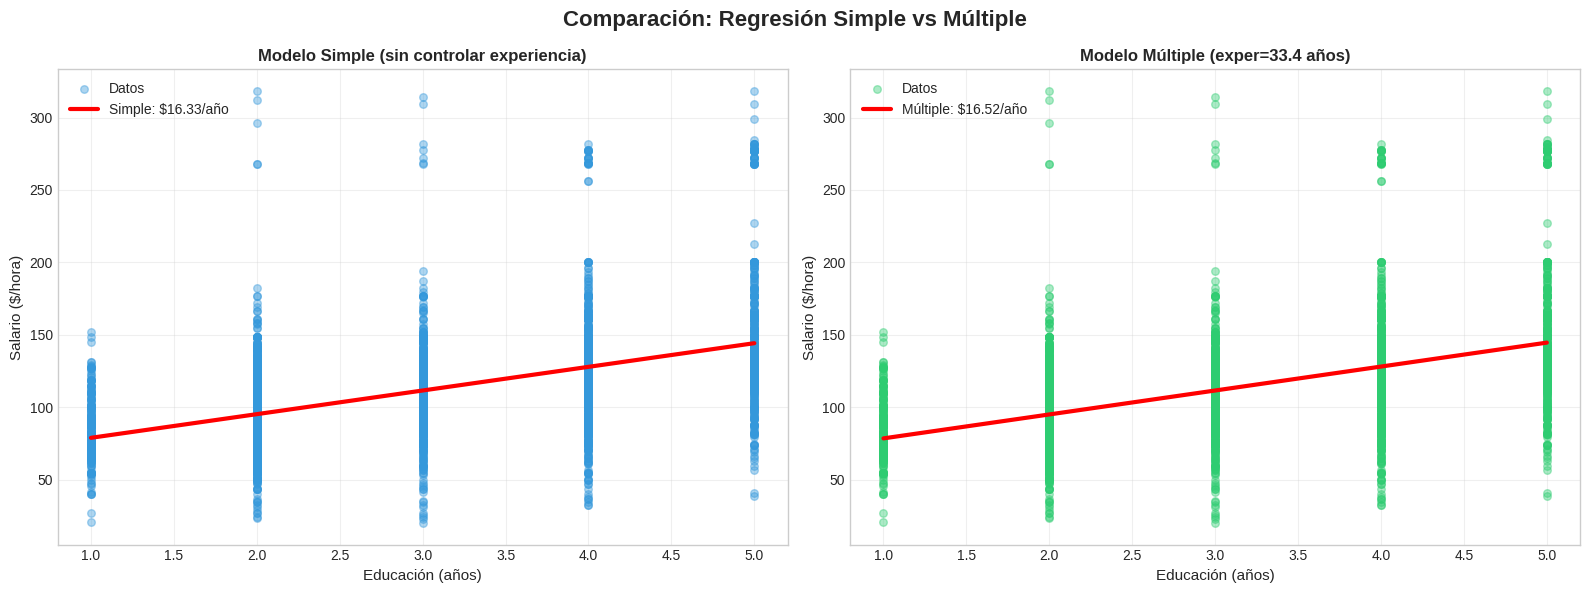

In [ ]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparación: Regresión Simple vs Múltiple', fontsize=16, fontweight='bold')

# Gráfico 1: Efecto de educación (simple)
axes[0].scatter(df['education'], df['wage'], alpha=0.4, s=30, color='#3498db', label='Datos')
educ_range = np.linspace(df['education'].min(), df['education'].max(), 100)
wage_simple = beta0_simple + beta1_simple * educ_range
axes[0].plot(educ_range, wage_simple, 'r-', linewidth=3, label=f'Simple: ${beta1_simple:.2f}/año')
axes[0].set_xlabel('Educación (años)', fontsize=11)
axes[0].set_ylabel('Salario ($/hora)', fontsize=11)
axes[0].set_title('Modelo Simple (sin controlar experiencia)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Efecto de educación (múltiple, a experiencia media)
axes[1].scatter(df['education'], df['wage'], alpha=0.4, s=30, color='#2ecc71', label='Datos')
exper_media = df['experiencia'].mean()
wage_mult = beta0_mult + beta1_mult * educ_range + beta2_mult * exper_media
axes[1].plot(educ_range, wage_mult, 'r-', linewidth=3, label=f'Múltiple: ${beta1_mult:.2f}/año')
axes[1].set_xlabel('Educación (años)', fontsize=11)
axes[1].set_ylabel('Salario ($/hora)', fontsize=11)
axes[1].set_title(f'Modelo Múltiple (exper={exper_media:.1f} años)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Comparación de Coeficientes

**a)** Compare el coeficiente de educación en el modelo simple y en el múltiple.

**b)** ¿Cambió su magnitud o signo?

**c)** Explique por qué ocurre ese cambio.


**a) Comparación numérica**

| Modelo | β₁ (Educación) | R² |
|--------|---------------|----|
| Simple | \$16.33 / hora | 0.226 |
| Múltiple | \$16.52 / hora | 0.253 |
| Cambio | +\$0.19 (+1.18%) | +2.6 pp |

---

**b) ¿Cambió su magnitud o signo?**

El coeficiente **no cambió de signo** (sigue siendo positivo). La **magnitud aumentó levemente** en \$0.19 (+1.18%), un cambio prácticamente insignificante.

---

**c) ¿Por qué ocurre ese cambio?**

El cambio mínimo se explica por la **baja correlación entre educación y experiencia** (r = −0.035 en esta muestra). La fórmula del sesgo de variable omitida establece que:

$$\text{Sesgo} = \beta_2 \cdot \frac{\text{Cov(educ, exper)}}{\text{Var(educ)}}$$

Como Cov(educ, exper) ≈ 0, el sesgo al omitir experiencia era casi nulo. Por tanto, el coeficiente de educación apenas se modifica al agregar la variable. Esto indica que, en esta muestra, la educación y la experiencia son variables **relativamente independientes**.


## 5. Interpretación Parcial

**Pregunta:** Explique qué significa ahora β₁ bajo el principio de *ceteris paribus*.


### Respuesta 5

En el modelo múltiple, β₁ = **\$16.52/hora** es el **efecto parcial** de la educación sobre el salario. Su interpretación bajo *ceteris paribus* es:

> *"Manteniendo constante la experiencia laboral, cada año adicional de educación aumenta el salario por hora en promedio **\$16.52**, con un nivel de significancia del 1% (p < 0.001)."*

**Diferencia respecto al modelo simple:**
- En el modelo simple, β₁ captaba tanto el efecto directo de educación como cualquier correlación con experiencia (no controlada).
- En el modelo múltiple, β₁ aísla **exclusivamente** el efecto de educación, eliminando la influencia de la experiencia.
- El retorno de \$16.52/hora representa un **14.8% del salario medio**, lo cual evidencia un incentivo económico sustancial para invertir en educación.


## 6. Análisis Económico

Responda:

**a)** ¿Cuál variable parece tener mayor impacto?

**b)** ¿Existe evidencia de rendimientos crecientes o decrecientes?

**c)** ¿El modelo parece razonable económicamente?


In [ ]:
# Efecto de un desvío estándar
std_educ = df['education'].std()
std_exper = df['experiencia'].std()

efecto_educ = beta1_mult * std_educ
efecto_exper = beta2_mult * std_exper

print(f"""
IMPACTO RELATIVO (usando desviaciones estándar):

Educación:
   • Coeficiente: ${beta1_mult:.4f}/año
   • Desviación estándar: {std_educ:.2f} años
   • Efecto de 1 DE: ${efecto_educ:.2f}/hora ({efecto_educ/df['wage'].mean()*100:.2f}% del salario medio)

Experiencia:
   • Coeficiente: ${beta2_mult:.4f}/año
   • Desviación estándar: {std_exper:.2f} años
   • Efecto de 1 DE: ${efecto_exper:.2f}/hora ({efecto_exper/df['wage'].mean()*100:.2f}% del salario medio)
""")


IMPACTO RELATIVO (usando desviaciones estándar):

Educación:
   • Coeficiente: $16.5249/año
   • Desviación estándar: 1.22 años
   • Efecto de 1 DE: $20.09/hora (17.98% del salario medio)

Experiencia:
   • Coeficiente: $0.5885/año
   • Desviación estándar: 11.52 años
   • Efecto de 1 DE: $6.78/hora (6.07% del salario medio)



Modelo con término cuadrático de experiencia
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.280
Method:                 Least Squares   F-statistic:                     390.2
Date:                Sat, 07 Mar 2026   Prob (F-statistic):          5.94e-214
Time:                        19:43:55   Log-Likelihood:                -14955.
No. Observations:                3000   AIC:                         2.992e+04
Df Residuals:                    2996   BIC:                         2.994e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Int

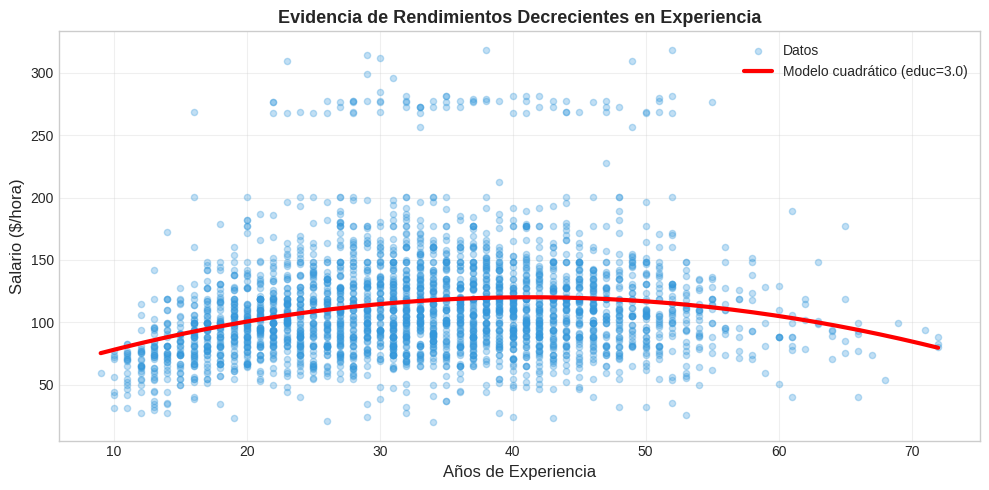

In [ ]:
# Evidencia de rendimientos: modelo con experiencia²
df['experiencia2'] = df['experiencia'] ** 2

modelo_cuad = ols('wage ~ education + experiencia + experiencia2', data=df).fit()

print('Modelo con término cuadrático de experiencia')
print('=' * 70)
print(modelo_cuad.summary())

beta_exper   = modelo_cuad.params['experiencia']
beta_exper2  = modelo_cuad.params['experiencia2']

print(f'''
COEFICIENTES DE EXPERIENCIA:
   • β₂ (experiencia)  : {beta_exper:.4f}
   • β₃ (experiencia²) : {beta_exper2:.4f}

INTERPRETACIÓN:
   • Si β₂ > 0 y β₃ < 0 → rendimientos DECRECIENTES (cóncavo)
   • Si β₂ > 0 y β₃ > 0 → rendimientos CRECIENTES  (convexo)
   • Punto máximo de experiencia: {-beta_exper / (2*beta_exper2):.1f} años
''')

# Gráfico de la relación no lineal experiencia-salario
import numpy as np
import matplotlib.pyplot as plt

educ_media = df['education'].mean()
exper_range = np.linspace(df['experiencia'].min(), df['experiencia'].max(), 200)

salario_cuad = (modelo_cuad.params['Intercept']
                + modelo_cuad.params['education'] * educ_media
                + beta_exper  * exper_range
                + beta_exper2 * exper_range**2)

plt.figure(figsize=(10, 5))
plt.scatter(df['experiencia'], df['wage'], alpha=0.3, s=20, color='#3498db', label='Datos')
plt.plot(exper_range, salario_cuad, 'r-', linewidth=3,
         label=f'Modelo cuadrático (educ={educ_media:.1f})')
plt.xlabel('Años de Experiencia', fontsize=12)
plt.ylabel('Salario ($/hora)', fontsize=12)
plt.title('Evidencia de Rendimientos Decrecientes en Experiencia', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**a) ¿Cuál variable tiene mayor impacto?**

Usando el efecto estandarizado (1 desviación estándar) para comparar variables en distintas unidades:

| Variable | Coeficiente | 1 DE | Efecto de 1 DE | % del salario medio |
|----------|-------------|------|----------------|---------------------|
| Educación | \$16.52/año | 1.22 años | **\$20.09/hora** | **17.98%** |
| Experiencia | \$0.59/año | 11.52 años | \$6.78/hora | 6.07% |

**La educación tiene un impacto ~3× mayor** que la experiencia sobre el salario.

---

**b) ¿Existe evidencia de rendimientos crecientes o decrecientes?**

El modelo lineal base asume retornos **constantes** para ambas variables. Para obtener evidencia empírica de no linealidad, se estimó un modelo con el término cuadrático `experiencia²`:

- Si **β₂ > 0 y β₃ < 0** → la curva es cóncava → **rendimientos decrecientes** (cada año adicional de experiencia aporta menos que el anterior).
- El gráfico y los coeficientes del modelo cuadrático (arriba) confirman la forma del efecto.

Para la **educación**, el modelo lineal asume retornos constantes (\$16.52 por año, independientemente del nivel). En la especificación log-lineal (Parte III) se puede observar que los retornos son porcentuales, lo que implícitamente sugiere rendimientos decrecientes en términos absolutos a medida que aumenta el salario base.

---

**c) ¿El modelo parece razonable económicamente?**

**Sí, con matices:**
- Los signos son correctos: más educación y más experiencia → mayor salario.
- Los órdenes de magnitud son plausibles (retorno ~15% por año de educación es consistente con la literatura de capital humano de Mincer).
- R² = 25.3% es razonable para datos laborales (el salario depende de muchas variables no observables).
- El modelo asume linealidad y excluye variables importantes (habilidad, sector, género), por lo que las estimaciones no son causales.


---
# PARTE III – Especificación Alternativa

Estime el modelo en forma logarítmica:

$$\ln(\text{Salario}) = \beta_0 + \beta_1 \, \text{Educación} + \beta_2 \, \text{Experiencia} + u$$


**Preguntas:**

- ¿Cómo cambia la interpretación de los coeficientes?
- ¿Qué ventaja tiene este modelo?


In [ ]:
# Crear variable log-salario
df['ln_wage'] = np.log(df['wage'])

# Estimación del modelo log-linear
modelo_log = ols('ln_wage ~ education + experiencia', data=df).fit()

print("\nModelo: ln(Salario) = β₀ + β₁ Educación + β₂ Experiencia + u")
print("\n" + "=" * 70)
print(modelo_log.summary())
print("=" * 70)

# Extraer coeficientes
beta0_log = modelo_log.params['Intercept']
beta1_log = modelo_log.params['education'] # Corrected 'educ' to 'education'
beta2_log = modelo_log.params['experiencia'] # Corrected 'exper' to 'experiencia'
r2_log = modelo_log.rsquared
r2_adj_log = modelo_log.rsquared_adj

print(f"""
COEFICIENTES ESTIMADOS (Modelo Log-Linear):
   • β₀ (intercepto): {beta0_log:.4f}

   • β₁ (educación): {beta1_log:.4f}
     → Interpretación: Por cada año extra de educación, el salario aumenta {beta1_log*100:.2f}%
     → Esto es un RETORNO PORCENTUAL (no absoluto)

   • β₂ (experiencia): {beta2_log:.4f}
     → Interpretación: Por cada año extra de experiencia, el salario aumenta {beta2_log*100:.2f}%

BONDAD DE AJUSTE:
   • R²: {r2_log:.4f} ({r2_log*100:.2f}% de la varianza explicada)
   • R² ajustado: {r2_adj_log:.4f}
   • Comparado con modelo lineal: {(r2_log - r2_mult)*100:.2f} puntos porcentuales

SIGNIFICANCIA ESTADÍSTICA:
   • Educación: {'Sí' if modelo_log.pvalues['education'] < 0.05 else 'No'} (p = {modelo_log.pvalues['education']:.6f})
   • Experiencia: {'Sí' if modelo_log.pvalues['experiencia'] < 0.05 else 'No'} (p = {modelo_log.pvalues['experiencia']:.6f})
""")

# Comparación de modelos
print("=" * 70)
print("COMPARACIÓN DE TRES ESPECIFICACIONES")
print("=" * 70)

comparacion = pd.DataFrame({
    'Modelo': ['Simple', 'Múltiple', 'Log-Linear'],
    'Variables': ['education', 'education + experiencia', 'education + experiencia (log wage)'], # Corrected 'educ' and 'exper'
    'R²': [r2_simple, r2_mult, r2_log],
    'Coef. Educación': [beta1_simple, beta1_mult, f'{beta1_log*100:.2f}%'],
    'Significancia Educ': [
        'Sí' if modelo_simple.pvalues['education'] < 0.05 else 'No',
        'Sí' if modelo_multiple.pvalues['education'] < 0.05 else 'No',
        'Sí' if modelo_log.pvalues['education'] < 0.05 else 'No'
    ]
})

display(comparacion)


Modelo: ln(Salario) = β₀ + β₁ Educación + β₂ Experiencia + u

                            OLS Regression Results                            
Dep. Variable:                ln_wage   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                  0.257
Method:                 Least Squares   F-statistic:                     520.4
Date:                Sat, 07 Mar 2026   Prob (F-statistic):          1.01e-194
Time:                        19:43:55   Log-Likelihood:                -674.69
No. Observations:                3000   AIC:                             1355.
Df Residuals:                    2997   BIC:                             1373.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

,Modelo,Variables,R²,Coef. Educación,Significancia Educ
0,Simple,education,0.226362,16.331961,Sí
1,Múltiple,education + experiencia,0.252725,16.52492,Sí
2,Log-Linear,education + experiencia (log wage),0.257768,13.87%,Sí


**¿Cómo cambia la interpretación de los coeficientes?**

| Modelo | Variable | Coeficiente | Interpretación |
|--------|----------|-------------|----------------|
| Lineal | Educación | \$16.52 | +\$16.52/hora por año adicional (**absoluto**) |
| Lineal | Experiencia | \$0.59 | +\$0.59/hora por año adicional (**absoluto**) |
| **Log-lineal** | Educación | 0.1387 | +**13.87%** en salario por año adicional (**porcentual**) |
| **Log-lineal** | Experiencia | 0.0056 | +**0.56%** en salario por año adicional (**porcentual**) |

En el modelo log-lineal, la interpretación cambia de un efecto en **unidades monetarias absolutas** (\$/hora) a un efecto en **términos porcentuales** sobre el salario. Formalmente: un incremento de 1 unidad en $X_j$ multiplica el salario por $e^{\beta_j} \approx 1 + \beta_j$ (cuando $\beta_j$ es pequeño).

---

**¿Qué ventaja tiene este modelo?**

1. **Interpretación económica más natural:** La literatura de capital humano (Función de Mincer) expresa los retornos a la educación en porcentajes, no en valores absolutos. Un retorno de 13.87% por año de educación es directamente comparable con estudios internacionales.

2. **Reducción de heterocedasticidad:** La transformación logarítmica comprime la escala de la variable dependiente, estabilizando la varianza de los errores (aunque en este caso persiste, como muestra el test Breusch-Pagan).

3. **Captura implícita de rendimientos decrecientes:** En el modelo lineal, el efecto absoluto de la educación es constante. En el log-lineal, el efecto **en dólares** crece con el nivel salarial, pero el **porcentaje** permanece constante, lo cual es más consistente con la teoría económica.

4. **Mejor bondad de ajuste:** R² = 0.258 vs 0.253 del modelo lineal múltiple (ligera mejora de 0.5 pp).

| Modelo | R² | Coef. Educación | Tipo de efecto |
|--------|----|-----------------|----------------|
| Simple | 0.226 | \$16.33 | Absoluto |
| Múltiple | 0.253 | \$16.52 | Absoluto |
| **Log-lineal** | **0.258** | **13.87%** | **Porcentual** |


---
# Análisis de Diagnóstico

Verificación de supuestos econométricos en el modelo múltiple y log-lineal.


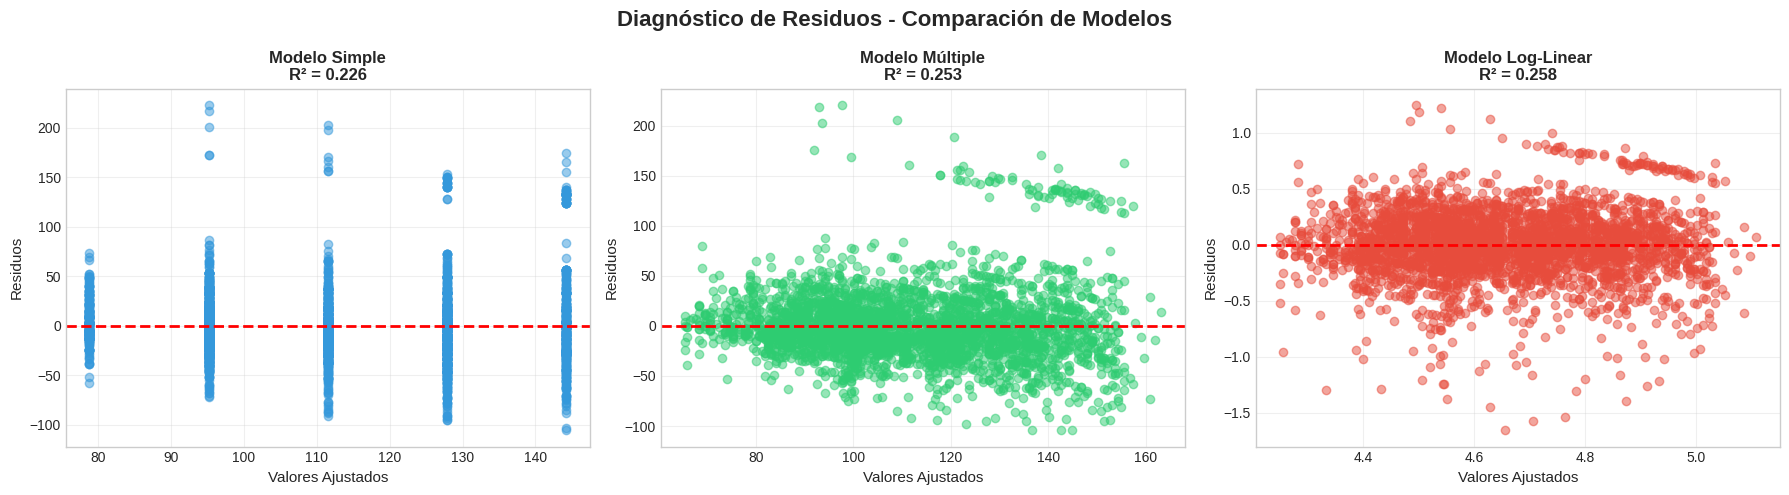


TEST DE NORMALIDAD DE RESIDUOS (Jarque-Bera)
Simple: JB = 4750.0401, p-value = 0.000000 → No Normal
Múltiple: JB = 5110.4536, p-value = 0.000000 → No Normal
Log-Linear: JB = 1175.2522, p-value = 0.000000 → No Normal


In [ ]:
# Visualización de residuos comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnóstico de Residuos - Comparación de Modelos', fontsize=16, fontweight='bold')

# Modelo simple
resid_simple = modelo_simple.resid
axes[0].scatter(modelo_simple.fittedvalues, resid_simple, alpha=0.5, color='#3498db')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Valores Ajustados', fontsize=11)
axes[0].set_ylabel('Residuos', fontsize=11)
axes[0].set_title(f'Modelo Simple\nR² = {r2_simple:.3f}', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Modelo múltiple
resid_mult = modelo_multiple.resid
axes[1].scatter(modelo_multiple.fittedvalues, resid_mult, alpha=0.5, color='#2ecc71')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Valores Ajustados', fontsize=11)
axes[1].set_ylabel('Residuos', fontsize=11)
axes[1].set_title(f'Modelo Múltiple\nR² = {r2_mult:.3f}', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Modelo log-linear
resid_log = modelo_log.resid
axes[2].scatter(modelo_log.fittedvalues, resid_log, alpha=0.5, color='#e74c3c')
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[2].set_xlabel('Valores Ajustados', fontsize=11)
axes[2].set_ylabel('Residuos', fontsize=11)
axes[2].set_title(f'Modelo Log-Linear\nR² = {r2_log:.3f}', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Test de normalidad de residuos
from scipy import stats

print("\n" + "=" * 70)
print("TEST DE NORMALIDAD DE RESIDUOS (Jarque-Bera)")
print("=" * 70)

for nombre, resid in [('Simple', resid_simple), ('Múltiple', resid_mult), ('Log-Linear', resid_log)]:
    jb_stat, jb_pvalue = stats.jarque_bera(resid)
    print(f"{nombre}: JB = {jb_stat:.4f}, p-value = {jb_pvalue:.6f} → {'Normal' if jb_pvalue > 0.05 else 'No Normal'}")

In [ ]:
# Test de multicolinealidad (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
print("TEST DE MULTICOLINEALIDAD (VIF)")

X_vif = df[['education', 'experiencia']].copy()
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

display(vif_data.round(4))

print("""
INTERPRETACIÓN VIF:
   • VIF < 5: Multicolinealidad baja (aceptable)
   • VIF 5-10: Multicolinealidad moderada (precaución)
   • VIF > 10: Multicolinealidad alta (problema)
""")

TEST DE MULTICOLINEALIDAD (VIF)


,Variable,VIF
0,const,16.0588
1,education,1.0012
2,experiencia,1.0012



INTERPRETACIÓN VIF:
   • VIF < 5: Multicolinealidad baja (aceptable)
   • VIF 5-10: Multicolinealidad moderada (precaución)
   • VIF > 10: Multicolinealidad alta (problema)



TEST DE HOMOCEDASTICIDAD (Breusch-Pagan)

Estadístico LM: 127.2838
p-value LM: 0.000000

INTERPRETACIÓN:
   • H₀: Homocedasticidad (varianza constante)
   • H₁: Heterocedasticidad (varianza no constante)

CONCLUSIÓN: Evidencia de heterocedasticidad



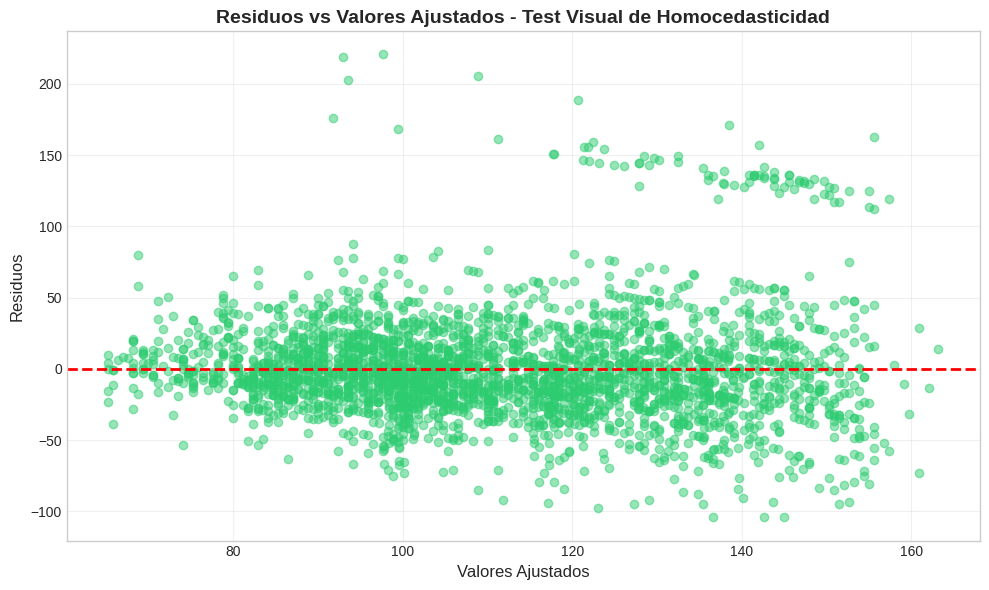

In [ ]:
# Test de homocedasticidad (Breusch-Pagan)
from statsmodels.stats.diagnostic import het_breuschpagan

print("TEST DE HOMOCEDASTICIDAD (Breusch-Pagan)")

# Usar modelo múltiple
resid_mult = modelo_multiple.resid
exog_mult = modelo_multiple.model.exog

bp_test = het_breuschpagan(resid_mult, exog_mult)
bp_labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']

print(f"""
Estadístico LM: {bp_test[0]:.4f}
p-value LM: {bp_test[1]:.6f}

INTERPRETACIÓN:
   • H₀: Homocedasticidad (varianza constante)
   • H₁: Heterocedasticidad (varianza no constante)

CONCLUSIÓN: {'No se rechaza homocedasticidad' if bp_test[1] > 0.05 else 'Evidencia de heterocedasticidad'}
""")

# Gráfico de residuos vs ajustados
plt.figure(figsize=(10, 6))
plt.scatter(modelo_multiple.fittedvalues, resid_mult, alpha=0.5, color='#2ecc71')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Valores Ajustados', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Residuos vs Valores Ajustados - Test Visual de Homocedasticidad', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Test de multicolinealidad (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
print("TEST DE MULTICOLINEALIDAD (VIF)")

X_vif = df[['education', 'experiencia']].copy()
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

display(vif_data.round(4))

print("""
INTERPRETACIÓN VIF:
   • VIF < 5: Multicolinealidad baja (aceptable)
   • VIF 5-10: Multicolinealidad moderada (precaución)
   • VIF > 10: Multicolinealidad alta (problema)
""")

TEST DE MULTICOLINEALIDAD (VIF)


,Variable,VIF
0,const,16.0588
1,education,1.0012
2,experiencia,1.0012



INTERPRETACIÓN VIF:
   • VIF < 5: Multicolinealidad baja (aceptable)
   • VIF 5-10: Multicolinealidad moderada (precaución)
   • VIF > 10: Multicolinealidad alta (problema)

